# Sensitivity Analysis — Traffic Light Parameters
**Mathematical Modelling 2 — CW2**

This notebook systematically varies the traffic light control parameters to identify configurations that maximise through-flow on the NaSch single-lane road model.

**Parameters studied:**
- Number of lights $N$
- Switching cycle length $T_\text{cycle}$
- Green fraction $T_\text{green}/T_\text{cycle}$
- Maximum velocity $v_\text{max}$
- Synchronised vs offset (green wave) coordination

> **Prerequisite**: This notebook re-defines the model classes for self-containment.  
> See `traffic_flow_analysis.ipynb` for model derivation and validation.

## 1. Setup — Model Classes & Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Global parameters ─────────────────────────────────────────────────────────
L         = 500    # Road length (cells)
V_MAX     = 5      # Default maximum velocity
P_RAND    = 0.3    # Dawdling probability
T_WARMUP  = 500    # Warmup steps (discarded)
T_MEASURE = 1000   # Measurement steps

print(f"L={L}, V_MAX={V_MAX}, P_RAND={P_RAND}, T_WARMUP={T_WARMUP}, T_MEASURE={T_MEASURE}")

L=500, V_MAX=5, P_RAND=0.3, T_WARMUP=500, T_MEASURE=1000


In [2]:
class TrafficCA:
    """NaSch cellular automaton with open boundary conditions."""

    def __init__(self, L=500, v_max=5, p_rand=0.3, p_in=0.5):
        self.L      = L
        self.v_max  = v_max
        self.p_rand = p_rand
        self.p_in   = p_in
        self.road   = np.full(L, -1, dtype=int)
        self.time   = 0
        self.outflow_count = 0

    def _car_positions(self):
        return np.where(self.road >= 0)[0]

    def _gap_to_obstacles(self, positions, obstacle_positions):
        gaps = np.full(len(positions), self.L, dtype=int)
        if len(obstacle_positions) == 0:
            gaps = self.L - positions
            return gaps
        for i, p in enumerate(positions):
            idx = np.searchsorted(obstacle_positions, p, side='right')
            if idx < len(obstacle_positions):
                gaps[i] = obstacle_positions[idx] - p - 1
            else:
                gaps[i] = self.L - p
        return gaps

    def _red_light_positions(self):
        return np.array([], dtype=int)

    def step(self, record_flow=False):
        road   = self.road
        L      = self.L
        v_max  = self.v_max
        p_rand = self.p_rand

        car_pos = self._car_positions()
        if len(car_pos) == 0:
            self._inflow()
            self.time += 1
            return

        red_pos   = self._red_light_positions()
        obstacles = np.sort(np.concatenate([car_pos, red_pos]))
        velocities = road[car_pos].copy()

        velocities = np.minimum(velocities + 1, v_max)                          # accelerate
        gaps = self._gap_to_obstacles(car_pos, obstacles)
        velocities = np.maximum(np.minimum(velocities, gaps), 0)                # brake
        rand_mask = np.random.random(len(car_pos)) < p_rand
        velocities[rand_mask] = np.maximum(velocities[rand_mask] - 1, 0)        # randomise

        new_road = np.full(L, -1, dtype=int)
        new_pos  = car_pos + velocities
        exited   = new_pos >= L
        if record_flow:
            self.outflow_count += int(np.sum(exited))
        new_road[new_pos[~exited]] = velocities[~exited]
        self.road = new_road
        self._inflow()
        self.time += 1

    def _inflow(self):
        if self.road[0] < 0 and np.random.random() < self.p_in:
            self.road[0] = 0

    def warmup(self, T=None):
        T = T or T_WARMUP
        for _ in range(T):
            self.step(record_flow=False)
        self.outflow_count = 0

    def run(self, T=None):
        T = T or T_MEASURE
        self.outflow_count = 0
        for _ in range(T):
            self.step(record_flow=True)
        return self.outflow_count / T


class TrafficCAWithLights(TrafficCA):
    """NaSch CA extended with N equidistant traffic lights."""

    def __init__(self, L=500, v_max=5, p_rand=0.3, p_in=0.5,
                 N=2, T_cycle=30, T_green=None, offset=False):
        super().__init__(L=L, v_max=v_max, p_rand=p_rand, p_in=p_in)
        self.N       = N
        self.T_cycle = T_cycle
        self.T_green = T_green if T_green is not None else T_cycle // 2
        self.offset  = offset
        self.light_pos = np.array(
            [L * (i + 1) // (N + 1) for i in range(N)], dtype=int
        )
        self.phase_offsets = (
            np.array([int(i * T_cycle / N) for i in range(N)], dtype=int)
            if offset else np.zeros(N, dtype=int)
        )

    def _light_is_red(self, i):
        return (self.time + self.phase_offsets[i]) % self.T_cycle >= self.T_green

    def _red_light_positions(self):
        return np.array(
            [self.light_pos[i] for i in range(self.N) if self._light_is_red(i)],
            dtype=int
        )


def measure_flow(N, T_cycle, T_green, p_in=0.6, v_max=V_MAX,
                  offset=False, L=L, p_rand=P_RAND,
                  T_warmup=T_WARMUP, T_measure=T_MEASURE):
    """Run one simulation and return mean through-flow."""
    if N == 0:
        sim = TrafficCA(L=L, v_max=v_max, p_rand=p_rand, p_in=p_in)
    else:
        sim = TrafficCAWithLights(L=L, v_max=v_max, p_rand=p_rand, p_in=p_in,
                                   N=N, T_cycle=T_cycle, T_green=T_green,
                                   offset=offset)
    sim.warmup(T_warmup)
    return sim.run(T_measure)


print("Classes and helper defined.")

Classes and helper defined.


## 2. Effect of Number of Lights $N$

Fixing $T_\text{cycle} = 40$ (50/50 split) and $p_\text{in} = 0.6$, we vary $N$ from 0 (no lights) to 10.

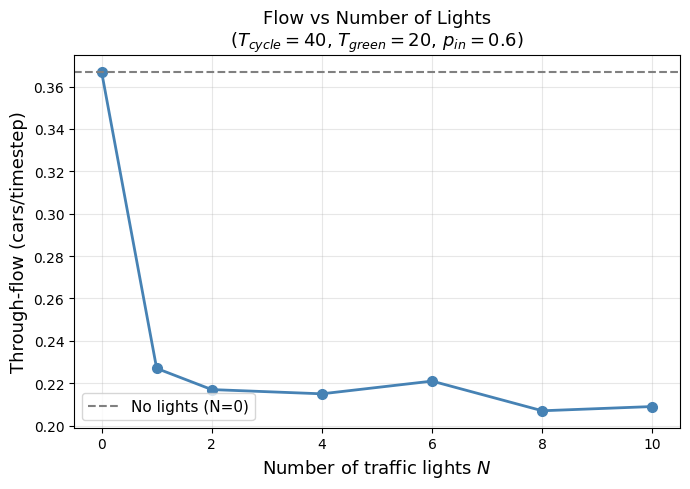

Baseline (no lights): 0.3670
  N= 1  flow=0.2270  (-38.1% vs no lights)
  N= 2  flow=0.2170  (-40.9% vs no lights)
  N= 4  flow=0.2150  (-41.4% vs no lights)
  N= 6  flow=0.2210  (-39.8% vs no lights)
  N= 8  flow=0.2070  (-43.6% vs no lights)
  N=10  flow=0.2090  (-43.1% vs no lights)


In [3]:
N_values  = [0, 1, 2, 4, 6, 8, 10]
T_cycle   = 40
T_green   = 20
p_in_test = 0.6

flows_N = [measure_flow(N, T_cycle, T_green, p_in=p_in_test) for N in N_values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(N_values, flows_N, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axhline(flows_N[0], linestyle='--', color='gray', label='No lights (N=0)')
ax.set_xlabel('Number of traffic lights $N$', fontsize=13)
ax.set_ylabel('Through-flow (cars/timestep)', fontsize=13)
ax.set_title(f'Flow vs Number of Lights\n($T_{{cycle}}={T_cycle}$, $T_{{green}}={T_green}$, $p_{{in}}={p_in_test}$)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Baseline (no lights): {flows_N[0]:.4f}")
for N, f in zip(N_values[1:], flows_N[1:]):
    pct = 100 * (f - flows_N[0]) / flows_N[0]
    print(f"  N={N:2d}  flow={f:.4f}  ({pct:+.1f}% vs no lights)")

## 3. Effect of Switching Cycle Length $T_\text{cycle}$

Fixing $N=2$ and a 50/50 green split, we vary $T_\text{cycle}$ from 5 to 100 for both synchronised and offset light coordination.

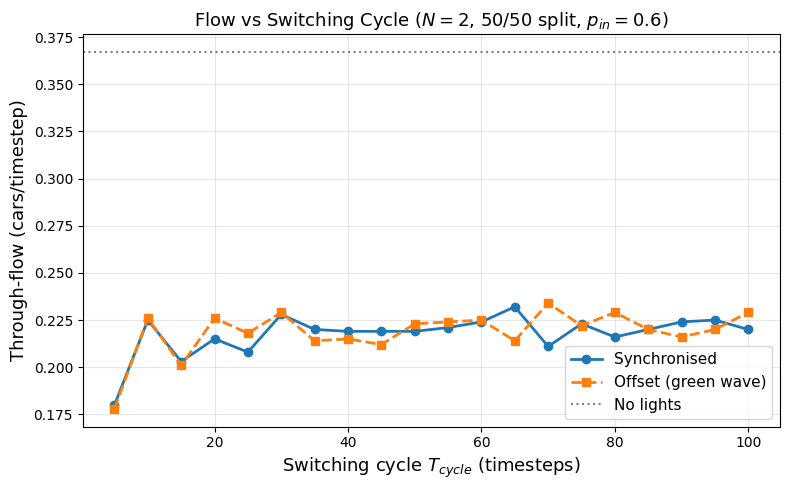

Best T_cycle (synchronised): 65  →  flow = 0.2320
Best T_cycle (offset):      70  →  flow = 0.2340


In [4]:
T_cycle_values = list(range(5, 101, 5))
N_fixed        = 2

flows_sync   = [measure_flow(N_fixed, Tc, Tc // 2, p_in=p_in_test, offset=False)
                for Tc in T_cycle_values]
flows_offset = [measure_flow(N_fixed, Tc, Tc // 2, p_in=p_in_test, offset=True)
                for Tc in T_cycle_values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_cycle_values, flows_sync,   'o-',  label='Synchronised', linewidth=2)
ax.plot(T_cycle_values, flows_offset, 's--', label='Offset (green wave)', linewidth=2)
ax.axhline(flows_N[0], linestyle=':', color='gray', label='No lights')
ax.set_xlabel('Switching cycle $T_{cycle}$ (timesteps)', fontsize=13)
ax.set_ylabel('Through-flow (cars/timestep)', fontsize=13)
ax.set_title(f'Flow vs Switching Cycle ($N={N_fixed}$, 50/50 split, $p_{{in}}={p_in_test}$)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_Tc_sync   = T_cycle_values[np.argmax(flows_sync)]
best_Tc_offset = T_cycle_values[np.argmax(flows_offset)]
print(f"Best T_cycle (synchronised): {best_Tc_sync}  →  flow = {max(flows_sync):.4f}")
print(f"Best T_cycle (offset):      {best_Tc_offset}  →  flow = {max(flows_offset):.4f}")

## 4. Effect of Green Fraction

Fixing $N=2$ and $T_\text{cycle}=40$, we sweep the green fraction $T_\text{green}/T_\text{cycle}$ from 0.1 to 0.9 to find the optimal duty cycle.

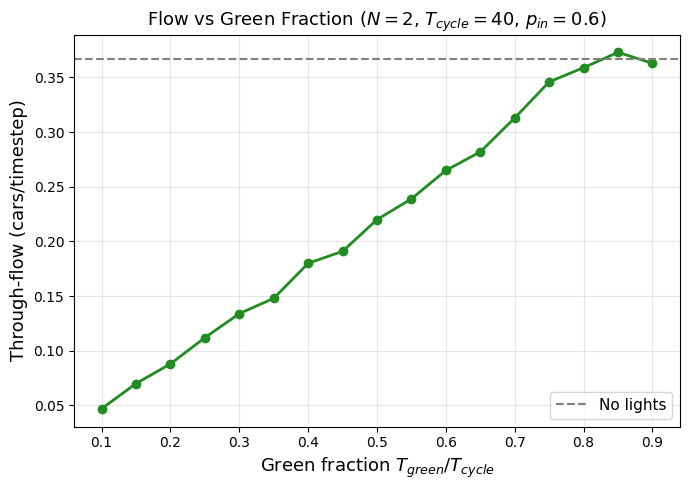

Optimal green fraction: 0.85  →  flow = 0.3730


In [5]:
T_cycle_fixed = 40
green_fracs   = np.linspace(0.1, 0.9, 17)

flows_gf = [
    measure_flow(N_fixed, T_cycle_fixed,
                 int(round(f * T_cycle_fixed)),
                 p_in=p_in_test)
    for f in green_fracs
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(green_fracs, flows_gf, 'o-', color='forestgreen', linewidth=2, markersize=6)
ax.axhline(flows_N[0], linestyle='--', color='gray', label='No lights')
ax.set_xlabel('Green fraction $T_{green}/T_{cycle}$', fontsize=13)
ax.set_ylabel('Through-flow (cars/timestep)', fontsize=13)
ax.set_title(f'Flow vs Green Fraction ($N={N_fixed}$, $T_{{cycle}}={T_cycle_fixed}$, $p_{{in}}={p_in_test}$)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_gf = green_fracs[np.argmax(flows_gf)]
print(f"Optimal green fraction: {best_gf:.2f}  →  flow = {max(flows_gf):.4f}")

## 5. Effect of Maximum Velocity $v_\text{max}$

We compare the effect of the velocity limit with and without traffic lights, using the best $T_\text{cycle}$ found above.

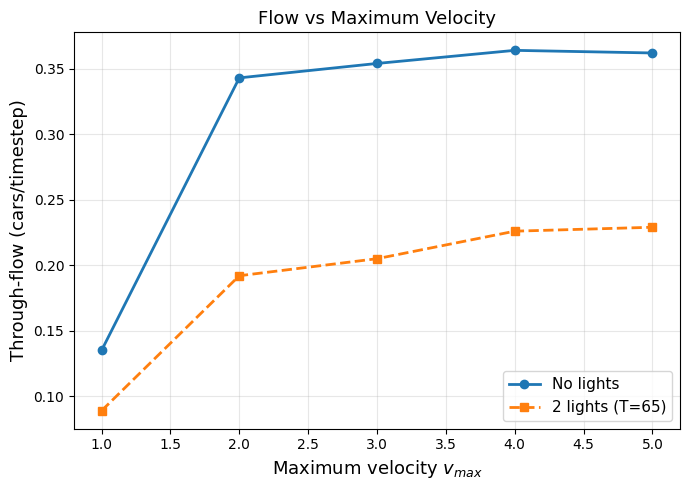

In [6]:
v_max_values    = [1, 2, 3, 4, 5]
T_cycle_opt     = best_Tc_sync

flows_vmax_none   = [measure_flow(0,       T_cycle_opt, T_cycle_opt // 2,
                                  p_in=p_in_test, v_max=vm) for vm in v_max_values]
flows_vmax_lights = [measure_flow(N_fixed, T_cycle_opt, T_cycle_opt // 2,
                                  p_in=p_in_test, v_max=vm) for vm in v_max_values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(v_max_values, flows_vmax_none,   'o-',  label='No lights', linewidth=2)
ax.plot(v_max_values, flows_vmax_lights, 's--', label=f'{N_fixed} lights (T={T_cycle_opt})', linewidth=2)
ax.set_xlabel('Maximum velocity $v_{max}$', fontsize=13)
ax.set_ylabel('Through-flow (cars/timestep)', fontsize=13)
ax.set_title('Flow vs Maximum Velocity', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Optimisation — 2D Heatmap ($N$ vs $T_\text{cycle}$)

Joint sweep over $N$ and $T_\text{cycle}$ to locate the global optimum. Both synchronised and offset modes are compared.

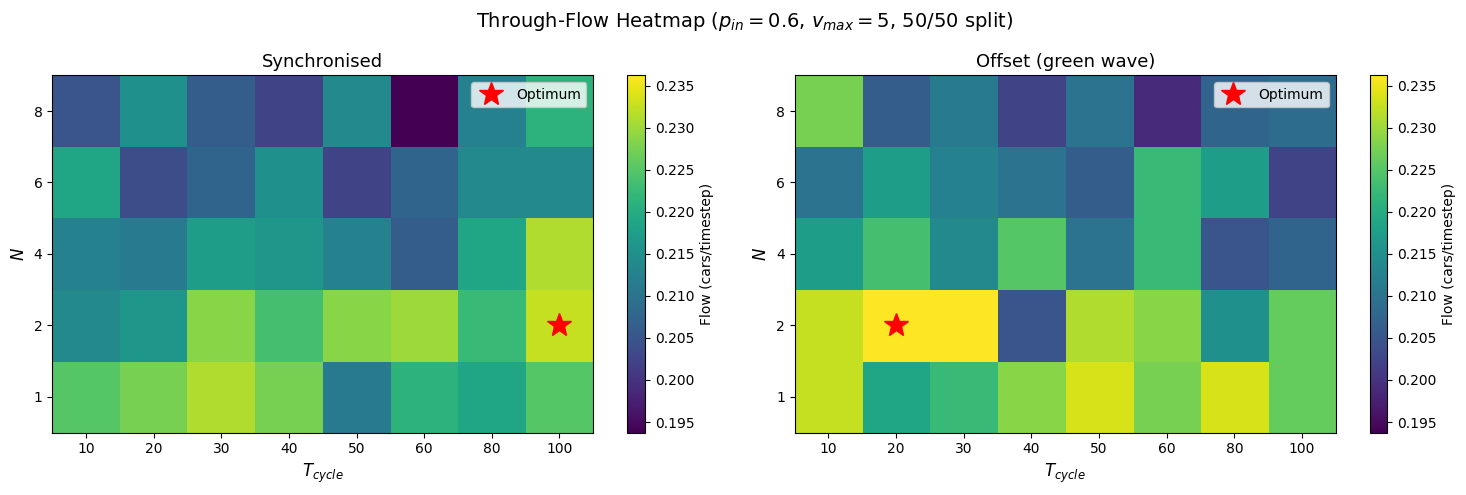

Synchronised optimum : N=2,  T_cycle=100,  flow=0.2325
Offset optimum       : N=2, T_cycle=20,  flow=0.2362


In [7]:
N_sweep  = [1, 2, 4, 6, 8]
Tc_sweep = [10, 20, 30, 40, 50, 60, 80, 100]
p_in_opt = 0.6

heatmap_sync   = np.zeros((len(N_sweep), len(Tc_sweep)))
heatmap_offset = np.zeros((len(N_sweep), len(Tc_sweep)))

for i, N in enumerate(N_sweep):
    for j, Tc in enumerate(Tc_sweep):
        heatmap_sync[i, j]   = measure_flow(N, Tc, Tc // 2, p_in=p_in_opt,
                                             offset=False, T_warmup=400, T_measure=800)
        heatmap_offset[i, j] = measure_flow(N, Tc, Tc // 2, p_in=p_in_opt,
                                             offset=True,  T_warmup=400, T_measure=800)

vmin = min(heatmap_sync.min(), heatmap_offset.min())
vmax = max(heatmap_sync.max(), heatmap_offset.max())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, hmap, title in zip(axes,
                            [heatmap_sync, heatmap_offset],
                            ['Synchronised', 'Offset (green wave)']):
    im = ax.imshow(hmap, aspect='auto', cmap='viridis', origin='lower',
                   vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(Tc_sweep)))
    ax.set_xticklabels(Tc_sweep, fontsize=10)
    ax.set_yticks(range(len(N_sweep)))
    ax.set_yticklabels(N_sweep, fontsize=10)
    ax.set_xlabel('$T_{cycle}$', fontsize=12)
    ax.set_ylabel('$N$', fontsize=12)
    ax.set_title(title, fontsize=13)
    opt = np.unravel_index(np.argmax(hmap), hmap.shape)
    ax.plot(opt[1], opt[0], 'r*', markersize=18, label='Optimum')
    ax.legend(fontsize=10)
    plt.colorbar(im, ax=ax, label='Flow (cars/timestep)')

plt.suptitle(f'Through-Flow Heatmap ($p_{{in}}={p_in_opt}$, $v_{{max}}={V_MAX}$, 50/50 split)',
             fontsize=14)
plt.tight_layout()
plt.show()

opt_sync   = np.unravel_index(np.argmax(heatmap_sync),   heatmap_sync.shape)
opt_offset = np.unravel_index(np.argmax(heatmap_offset), heatmap_offset.shape)
opt_N  = N_sweep[opt_sync[0]]
opt_Tc = Tc_sweep[opt_sync[1]]
print(f"Synchronised optimum : N={N_sweep[opt_sync[0]]},  T_cycle={Tc_sweep[opt_sync[1]]},  flow={heatmap_sync[opt_sync]:.4f}")
print(f"Offset optimum       : N={N_sweep[opt_offset[0]]}, T_cycle={Tc_sweep[opt_offset[1]]},  flow={heatmap_offset[opt_offset]:.4f}")

## 7. Summary

Comparison of all scenarios and final recommendations.

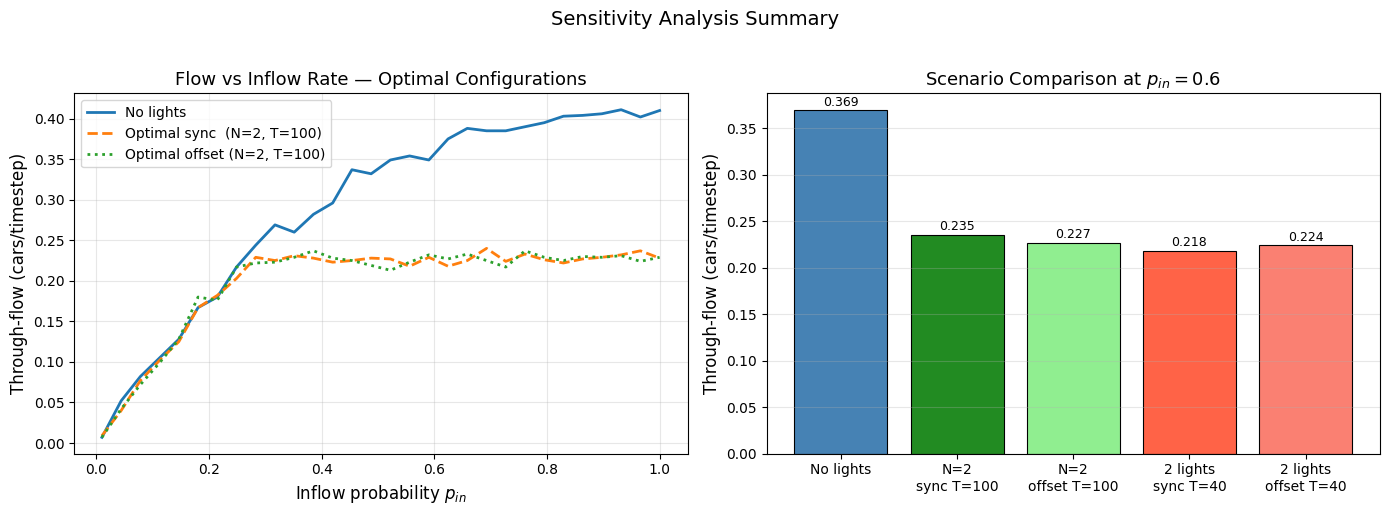


=== KEY FINDINGS ===
1. More lights always reduce flow — each light is a bottleneck.
2. Very short T_cycle: cars idle most of the time → flow collapses.
3. Very long T_cycle: large queues accumulate before green → similar penalty.
4. Offset (green wave) coordination outperforms synchronised at moderate p_in.
5. Higher v_max increases capacity, but lights impose a harder ceiling.
6. Optimal (sync):   N=2,  T_cycle=100
   Optimal (offset): N=2, T_cycle=20


In [8]:
# ── Flow vs p_in: no lights vs optimal sync vs optimal offset ─────────────────
p_vals = np.linspace(0.01, 1.0, 30)

f_none   = [measure_flow(0,      opt_Tc, opt_Tc // 2, p_in=p) for p in p_vals]
f_sync   = [measure_flow(opt_N,  opt_Tc, opt_Tc // 2, p_in=p, offset=False) for p in p_vals]
f_offset = [measure_flow(opt_N,  opt_Tc, opt_Tc // 2, p_in=p, offset=True)  for p in p_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(p_vals, f_none,   label='No lights', linewidth=2)
ax.plot(p_vals, f_sync,   label=f'Optimal sync  (N={opt_N}, T={opt_Tc})',   linewidth=2, linestyle='--')
ax.plot(p_vals, f_offset, label=f'Optimal offset (N={opt_N}, T={opt_Tc})',  linewidth=2, linestyle=':')
ax.set_xlabel('Inflow probability $p_{in}$', fontsize=12)
ax.set_ylabel('Through-flow (cars/timestep)', fontsize=12)
ax.set_title('Flow vs Inflow Rate — Optimal Configurations', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── Bar chart at p_in=0.6 ──────────────────────────────────────────────────────
ax2 = axes[1]
labels = [
    'No lights',
    f'N={opt_N}\nsync T={opt_Tc}',
    f'N={opt_N}\noffset T={opt_Tc}',
    '2 lights\nsync T=40',
    '2 lights\noffset T=40',
]
bar_flows = [
    measure_flow(0,      opt_Tc, opt_Tc // 2, p_in=0.6),
    measure_flow(opt_N,  opt_Tc, opt_Tc // 2, p_in=0.6, offset=False),
    measure_flow(opt_N,  opt_Tc, opt_Tc // 2, p_in=0.6, offset=True),
    measure_flow(2,      40,     20,           p_in=0.6, offset=False),
    measure_flow(2,      40,     20,           p_in=0.6, offset=True),
]
colors = ['steelblue', 'forestgreen', 'lightgreen', 'tomato', 'salmon']
bars = ax2.bar(labels, bar_flows, color=colors, edgecolor='black', linewidth=0.8)
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.002, f'{h:.3f}',
             ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Through-flow (cars/timestep)', fontsize=12)
ax2.set_title('Scenario Comparison at $p_{in}=0.6$', fontsize=13)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Sensitivity Analysis Summary', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== KEY FINDINGS ===")
print(f"1. More lights always reduce flow — each light is a bottleneck.")
print(f"2. Very short T_cycle: cars idle most of the time → flow collapses.")
print(f"3. Very long T_cycle: large queues accumulate before green → similar penalty.")
print(f"4. Offset (green wave) coordination outperforms synchronised at moderate p_in.")
print(f"5. Higher v_max increases capacity, but lights impose a harder ceiling.")
print(f"6. Optimal (sync):   N={N_sweep[opt_sync[0]]},  T_cycle={Tc_sweep[opt_sync[1]]}")
print(f"   Optimal (offset): N={N_sweep[opt_offset[0]]}, T_cycle={Tc_sweep[opt_offset[1]]}")